In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [52]:
matches = pd.read_csv("data/matches.csv")
deliveries = pd.read_csv("data/deliveries.csv")

print("Matches rows:", matches.shape[0])
print("Deliveries rows:", deliveries.shape[0])

Matches rows: 1095
Deliveries rows: 260920


In [53]:
import os
print(os.listdir("data/"))

['deliveries.csv', 'IPLPlayerAuctionData.csv', 'matches.csv']


In [54]:
matches = pd.read_csv("data/matches.csv")
deliveries = pd.read_csv("data/deliveries.csv")
auction = pd.read_csv("data/IPLPlayerAuctionData.csv")

print("Matches rows:", matches.shape[0])
print("Deliveries rows:", deliveries.shape[0])
print("Auction rows:", auction.shape[0])

Matches rows: 1095
Deliveries rows: 260920
Auction rows: 970


In [58]:
print("=== AUCTION COLUMNS ===")
print(auction.columns.tolist())

print("\n=== AUCTION FIRST 5 ROWS ===")
print(auction.head())

=== AUCTION COLUMNS ===
['Player', 'Role', 'Amount', 'Team', 'Year', 'Player Origin']

=== AUCTION FIRST 5 ROWS ===
        Player     Role    Amount                         Team    Year  \
0  Aaron Finch  Batsman  40000000          Sunrisers Hyderabad  2014.0   
1  Aaron Finch  Batsman  32000000               Mumbai Indians  2015.0   
2  Aaron Finch  Batsman  10000000                Gujarat Lions  2016.0   
3  Aaron Finch  Batsman  62000000              Kings XI Punjab  2018.0   
4  Aaron Finch  Batsman  44000000  Royal Challengers Bangalore  2020.0   

  Player Origin  
0      Overseas  
1      Overseas  
2      Overseas  
3      Overseas  
4      Overseas  


In [59]:
print(deliveries.columns.tolist())
print(deliveries.head())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1  

In [60]:
batting_stats = deliveries.groupby("batter")["batsman_runs"].sum().reset_index()
batting_stats.columns = ["Player", "Total_Runs"]

print(batting_stats.sort_values("Total_Runs", ascending=False).head(10))

             Player  Total_Runs
631         V Kohli        8014
512        S Dhawan        6769
477       RG Sharma        6630
147       DA Warner        6567
546        SK Raina        5536
374        MS Dhoni        5243
30   AB de Villiers        5181
124        CH Gayle        4997
501      RV Uthappa        4954
282      KD Karthik        4843


In [61]:
auction = auction.fillna(0).drop_duplicates()
batting_stats = batting_stats.drop_duplicates()

player_value = pd.merge(batting_stats, auction, on="Player", how="inner")

print("Players matched:", len(player_value))
print(player_value[["Player", "Total_Runs", "Amount", "Team"]].head(10))

Players matched: 100
             Player  Total_Runs    Amount                         Team
0       Abdul Samad         579   2000000          Sunrisers Hyderabad
1   Abhishek Sharma        1377   5500000             Delhi Daredevils
2   Abhishek Sharma        1377  65000000          Sunrisers Hyderabad
3        Akash Deep          19   2000000  Royal Challengers Bangalore
4      Ankit Sharma          87   1000000       Rising Pune Supergiant
5      Ankit Sharma          87   2000000             Rajasthan Royals
6  Anmolpreet Singh         139   8000000               Mumbai Indians
7  Anmolpreet Singh         139   2000000               Mumbai Indians
8        Anuj Rawat         318   8000000             Rajasthan Royals
9        Anuj Rawat         318  34000000  Royal Challengers Bangalore


In [62]:
player_value = player_value[player_value["Amount"] > 0]

player_value["Amount_Crores"] = player_value["Amount"] / 10000000

player_value["Value_Score"] = (player_value["Total_Runs"] / player_value["Amount_Crores"])

player_value = player_value.sort_values("Value_Score", ascending=False).reset_index(drop=True)

print(player_value[["Player", "Total_Runs", "Amount_Crores", "Value_Score"]].head(10))

            Player  Total_Runs  Amount_Crores  Value_Score
0     Ishan Kishan        2644           0.35  7554.285714
1         KL Rahul        4689           1.00  4689.000000
2   Shashank Singh         423           0.10  4230.000000
3      Abdul Samad         579           0.20  2895.000000
4     Yuvraj Singh        2754           1.00  2754.000000
5  Abhishek Sharma        1377           0.55  2503.636364
6   Shashank Singh         423           0.20  2115.000000
7     Shubman Gill        3216           1.80  1786.666667
8      Dhruv Jurel         347           0.20  1735.000000
9    Mandeep Singh        1706           1.10  1550.909091


In [63]:
player_value = player_value.sort_values("Amount", ascending=False)
player_value = player_value.drop_duplicates(subset="Player", keep="first")
player_value = player_value.reset_index(drop=True)

print("Players after fix:", len(player_value))
print(player_value[["Player", "Total_Runs", "Amount", "Team"]].head(10))

Players after fix: 54
              Player  Total_Runs     Amount                   Team
0       Yuvraj Singh        2754  160000000       Delhi Daredevils
1       Ishan Kishan        2644  152500000         Mumbai Indians
2           KL Rahul        4689  110000000        Kings XI Punjab
3         Avesh Khan          41  100000000   Lucknow Super Giants
4  Washington Sundar         378   87500000    Sunrisers Hyderabad
5        Shivam Mavi          51   72500000  Kolkata Knight Riders
6    Abhishek Sharma        1377   65000000    Sunrisers Hyderabad
7      Kuldeep Yadav         183   58000000  Kolkata Knight Riders
8       Kartik Tyagi          13   40000000    Sunrisers Hyderabad
9      Harpreet Brar         233   38000000           Punjab Kings


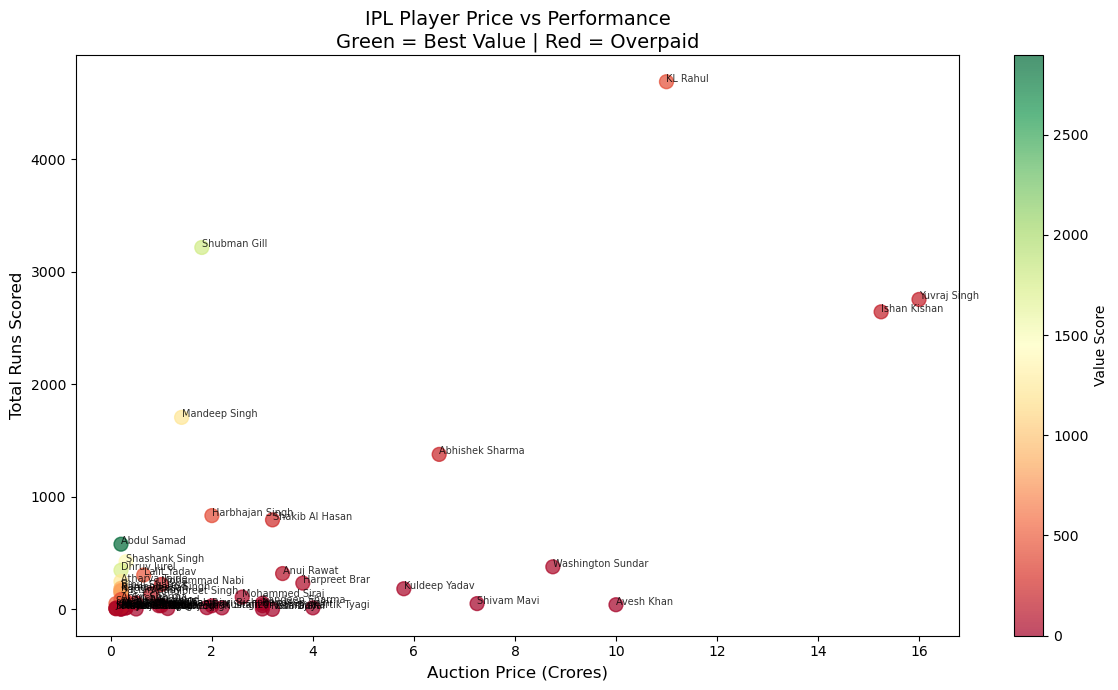

In [65]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    player_value["Amount_Crores"],
    player_value["Total_Runs"],
    c=player_value["Value_Score"],
    cmap="RdYlGn",
    s=100,
    alpha=0.7
)

plt.colorbar(scatter, label="Value Score")

for i, row in player_value.iterrows():
    plt.annotate(
        row["Player"],
        (row["Amount_Crores"], row["Total_Runs"]),
        fontsize=7,
        alpha=0.8
    )

plt.xlabel("Auction Price (Crores)", fontsize=12)
plt.ylabel("Total Runs Scored", fontsize=12)
plt.title("IPL Player Price vs Performance\nGreen = Best Value | Red = Overpaid", fontsize=14)
plt.tight_layout()
plt.savefig("output/scatter_price_vs_performance.png", dpi=150)
plt.show()

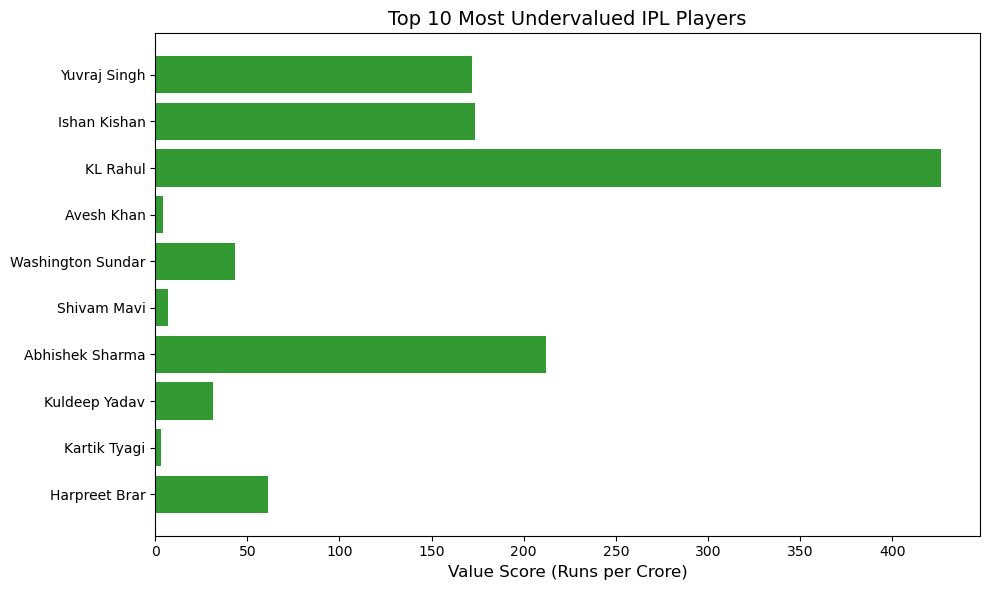

In [68]:
top10 = player_value.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["Player"], top10["Value_Score"], color="green", alpha=0.8)
plt.xlabel("Value Score (Runs per Crore)", fontsize=12)
plt.title("Top 10 Most Undervalued IPL Players", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("output/best_value_players.png", dpi=150)
plt.show()

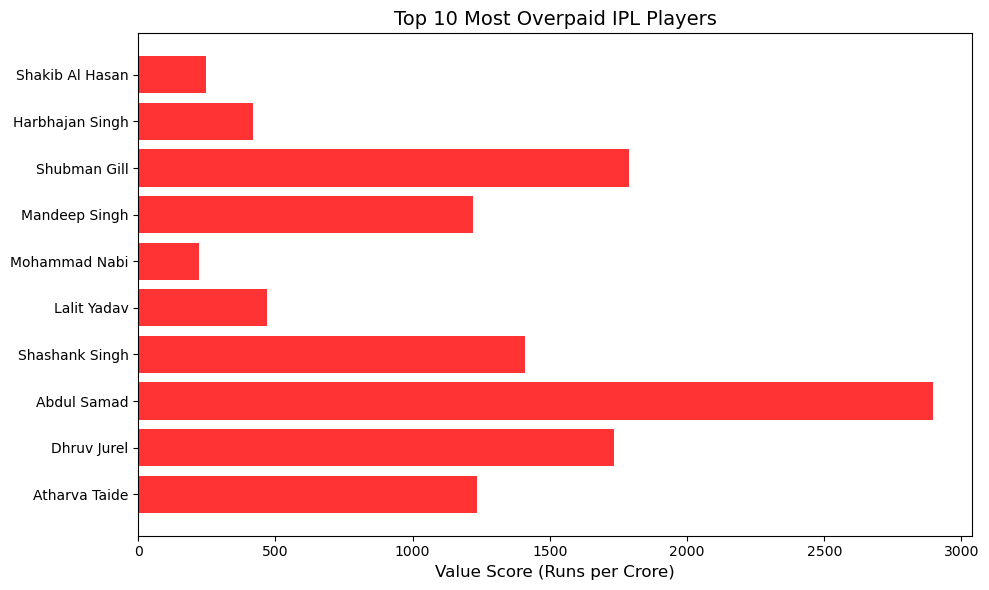

In [67]:
overpaid = player_value[player_value["Total_Runs"] > 200].tail(10)

plt.figure(figsize=(10, 6))
plt.barh(overpaid["Player"], overpaid["Value_Score"], color="red", alpha=0.8)
plt.xlabel("Value Score (Runs per Crore)", fontsize=12)
plt.title("Top 10 Most Overpaid IPL Players", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("output/most_overpaid_players.png", dpi=150)
plt.show()

In [69]:
player_value.to_csv("output/ipl_player_value_final.csv", index=False)